# Decoding YouTube's Grip on Global Attention — ML Analysis

This notebook covers the core ML and statistical analyses:
1. BERTopic sub-topic extraction with noise reduction across all 5 major categories
2. Kaplan-Meier survival analysis on trending durations
3. DBSCAN country clustering to discover "attention archetypes"
4. Convergence metrics: Shannon entropy, topic variety, cross-country similarity, churn rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#0f0f0f',
    'axes.labelcolor': 'white', 'xtick.color': 'white',
    'ytick.color': 'white', 'text.color': 'white',
    'axes.titlecolor': 'white', 'legend.facecolor': '#1a1a1a',
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROJDIR = './'

In [2]:
print("Loading dataset...")
df = pd.read_csv(f'{PROJDIR}final_dataset_full_with_channel_stats.csv', low_memory=False)
print(f"Raw shape: {df.shape}")

# drop stray header rows that got concatenated during export
df = df[df['snapshot_type'].isin(['entry', 'peak', 'exit'])].reset_index(drop=True)
print(f"After cleanup: {df.shape}")

Loading dataset...
Raw shape: (8371826, 21)
After cleanup: (8371824, 21)


In [3]:
# dtype fixes — some columns read as object because of stray header rows
for col in ['rank', 'view_count', 'comment_count', 'category_id',
            'time_to_trend', 'trending_duration', 'subscriber_count',
            'channel_video_count', 'channel_view_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['collection_date'] = pd.to_datetime(df['collection_date'], format='mixed', utc=True)
df['published_at'] = pd.to_datetime(df['published_at'], format='mixed', utc=True)
df['first_seen'] = pd.to_datetime(df['first_seen'], format='mixed', utc=True)
df['time_to_trend'] = df['time_to_trend'].clip(lower=0)

# YouTube category label map
CAT_MAP = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music',
    15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies',
    19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging',
    22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment',
    25: 'News & Politics', 26: 'Howto & Style', 27: 'Education',
    28: 'Science & Technology', 29: 'Nonprofits & Activism',
    30: 'Movies', 43: 'Shows', 44: 'Trailers'
}
df['category_label'] = df['category_id'].map(CAT_MAP)

# entry snapshots + derived features
entry = df[df['snapshot_type'] == 'entry'].copy()
entry['engagement_depth'] = entry['comment_count'] / entry['view_count'].replace(0, np.nan)
entry['year'] = entry['first_seen'].dt.year
entry['month'] = entry['first_seen'].dt.to_period('M')

print(f"Entry rows: {entry.shape[0]}")
print(f"\nTop 5 categories:")
print(entry['category_label'].value_counts().head())

Entry rows: 2804358

Top 5 categories:
category_label
Entertainment     778743
Gaming            361003
People & Blogs    358812
Sports            356065
Music             309537
Name: count, dtype: int64


In [4]:
# one row per video — keep earliest region appearance (for BERTopic)
entry_sorted = entry.sort_values('first_seen')
df_unique = entry_sorted.drop_duplicates(subset='video_id', keep='first').reset_index(drop=True)
df_unique['text_for_nlp'] = df_unique['text_for_nlp'].fillna(df_unique['title'].fillna(''))

embeddings = np.load(f'{PROJDIR}embeddings.npy')
print(f"Unique videos: {df_unique.shape[0]}, Embeddings: {embeddings.shape}")
assert embeddings.shape[0] == df_unique.shape[0], "Mismatch!"

print(f"Date range: {entry['first_seen'].min()} to {entry['first_seen'].max()}")
print(f"Regions: {entry['region_code'].nunique()}")
print(f"Years: {sorted(entry['year'].unique())}")

Unique videos: 725789, Embeddings: (725789, 384)
Date range: 2022-07-01 00:00:00+00:00 to 2025-06-30 18:00:00+00:00
Regions: 104
Years: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


## BERTopic — Sub-topic Extraction with Noise Reduction

Running BERTopic per-category (top 5 YouTube categories) to handle multilingual noise. Each category's videos are clustered separately so language diversity within a single corpus is reduced.

After initial clustering, we apply `reduce_outliers(strategy="embeddings", threshold=0.5)` to reassign noise documents to their nearest topic based on embedding distance. We keep the original topic keyword representations to preserve sub-topic diversity.

In [5]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

df_unique_cat = df_unique.copy()

category_configs = {
    'Entertainment':   {'min_cluster_size': 350, 'min_samples': 15},
    'People & Blogs':  {'min_cluster_size': 200, 'min_samples': 15},
    'Sports':          {'min_cluster_size': 100, 'min_samples': 10},
    'Gaming':          {'min_cluster_size': 100, 'min_samples': 10},
    'Music':           {'min_cluster_size': 100, 'min_samples': 10},
}

all_results = {}

for category, cfg in category_configs.items():
    print(f"\n{'='*60}")
    print(f" {category}")
    print(f"{'='*60}")

    mask = df_unique_cat['category_label'] == category
    df_cat = df_unique_cat[mask].reset_index(drop=True)
    cat_indices = df_unique_cat[mask].index.to_numpy()
    emb_cat = embeddings[cat_indices]
    docs = df_cat['text_for_nlp'].tolist()
    print(f"  docs: {len(docs)}")

    umap_model = UMAP(
        n_neighbors=15, n_components=5, min_dist=0.0,
        metric='cosine', random_state=42
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=cfg['min_cluster_size'],
        min_samples=cfg['min_samples'],
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True, core_dist_n_jobs=1
    )
    vectorizer = CountVectorizer(
        stop_words='english', min_df=10, ngram_range=(1, 2),
        token_pattern=r"(?u)\b(?!unknown\b)[a-zA-Z][a-zA-Z]+\b"
    )

    topic_model = BERTopic(
        umap_model=umap_model, hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer, nr_topics='auto', verbose=False
    )
    topics, probs = topic_model.fit_transform(docs, embeddings=emb_cat)

    noise_before = (np.array(topics) == -1).mean()
    print(f"  noise BEFORE: {noise_before:.1%}")
    n_topics_before = len(set(topics)) - (1 if -1 in topics else 0)

    # save the original topic keywords BEFORE outlier reduction
    original_keywords = {}
    for tid in topic_model.get_topic_info()['Topic']:
        if tid == -1: continue
        original_keywords[tid] = [w for w, _ in topic_model.get_topic(tid)[:5]]

    # reduce outliers — assign noise docs to nearest topic via embeddings
    # threshold=0.5 is more conservative than 0.3 (keeps truly ambiguous docs as noise)
    new_topics = topic_model.reduce_outliers(
        docs, topics, strategy="embeddings",
        embeddings=emb_cat, threshold=0.5
    )
    # DO NOT call update_topics — preserve original keyword representations

    noise_after = (np.array(new_topics) == -1).mean()
    print(f"  noise AFTER:  {noise_after:.1%}")
    print(f"  topics: {n_topics_before}")

    df_cat['topic_id'] = new_topics
    df_cat['year'] = pd.to_datetime(df_cat['first_seen']).dt.year

    all_results[category] = {
        'df': df_cat,
        'model': topic_model,
        'keywords': original_keywords,
        'noise_before': noise_before,
        'noise_after': noise_after,
    }

    # show top subtopics with ORIGINAL keywords
    for tid in list(original_keywords.keys())[:8]:
        count = (np.array(new_topics) == tid).sum()
        print(f"    Topic {tid} ({count} docs): {original_keywords[tid]}")

print("\nAll categories done.")


 Entertainment
  docs: 205063
  noise BEFORE: 52.7%
  noise AFTER:  17.1%
  topics: 26
    Topic 0 (114108 docs): ['tv', 'episode', 'serial', 'new', 'drama']
    Topic 1 (8846 docs): ['tv', 'episode', 'serial', 'new', 'drama']
    Topic 2 (5082 docs): ['tv', 'episode', 'new', 'video', 'la']
    Topic 3 (7688 docs): ['tv', 'episode', 'new', 'drama', 'comedy']
    Topic 4 (3209 docs): ['tv', 'serial', 'episode', 'new', 'drama']
    Topic 5 (2933 docs): ['tv', 'new', 'episode', 'video', 'serial']
    Topic 6 (4876 docs): ['movies', 'tv', 'new', 'latest', 'la']
    Topic 7 (2203 docs): ['serial', 'tv', 'episode', 'latest', 'tamil']

 People & Blogs
  docs: 98664
  noise BEFORE: 50.6%
  noise AFTER:  9.7%
  topics: 50
    Topic 0 (9104 docs): ['vlogs', 'vlog', 'family', 'joshi', 'new']
    Topic 1 (9520 docs): ['vlog', 'vlogs', 'shorts', 'family', 'funny']
    Topic 2 (8015 docs): ['vlog', 'shorts', 'vlogs', 'family', 'tv']
    Topic 3 (6691 docs): ['vlog', 'vlogs', 'shorts', 'family', 'ba

In [6]:
# noise reduction summary
print(f"{'Category':<20} {'Raw Noise':>10} {'Reduced':>10} {'Improvement':>12}")
print("-" * 55)
for cat, res in all_results.items():
    b, a = res['noise_before'], res['noise_after']
    print(f"{cat:<20} {b:>9.1%} {a:>9.1%} {b - a:>11.1%}")

# within-category Shannon entropy (sub-topics) by year
def shannon_entropy(series):
    counts = series.value_counts(normalize=True)
    return -(counts * np.log2(counts)).sum()

print(f"\n\nSub-topic entropy by year:")
print(f"{'Category':<20} {'2022':>8} {'2023':>8} {'2024':>8} {'2025':>8}")
print("-" * 56)
for cat, res in all_results.items():
    dfc = res['df'][res['df']['topic_id'] != -1]
    ent_by_year = dfc.groupby('year')['topic_id'].apply(shannon_entropy)
    vals = [f"{ent_by_year.get(y, 0):.3f}" for y in [2022, 2023, 2024, 2025]]
    print(f"{cat:<20} {'  '.join(vals)}")

# topic variety by year
print(f"\n\nDistinct sub-topics by year:")
print(f"{'Category':<20} {'2022':>6} {'2023':>6} {'2024':>6} {'2025':>6}")
print("-" * 48)
for cat, res in all_results.items():
    dfc = res['df'][res['df']['topic_id'] != -1]
    variety = dfc.groupby('year')['topic_id'].nunique()
    vals = [f"{variety.get(y, 0):>6d}" for y in [2022, 2023, 2024, 2025]]
    print(f"{cat:<20} {''.join(vals)}")

Category                 Before      After    Reduction
-------------------------------------------------------
Entertainment            52.7%     17.1%       35.6%
People & Blogs           50.6%      9.7%       40.8%
Sports                   47.9%      6.7%       41.2%
Gaming                   50.9%      6.6%       44.3%
Music                    49.6%      7.7%       41.9%


Sub-topic entropy by year:
Category                 2022     2023     2024     2025
--------------------------------------------------------
Entertainment        2.227  2.319  2.259  2.224
People & Blogs       4.867  4.890  4.868  4.844
Sports               5.465  5.484  5.469  5.381
Gaming               6.049  6.068  6.021  5.977
Music                5.542  5.560  5.472  5.453


Distinct sub-topics by year:
Category               2022   2023   2024   2025
------------------------------------------------
Entertainment            26    26    26    26
People & Blogs           50    50    50    50
Sports             

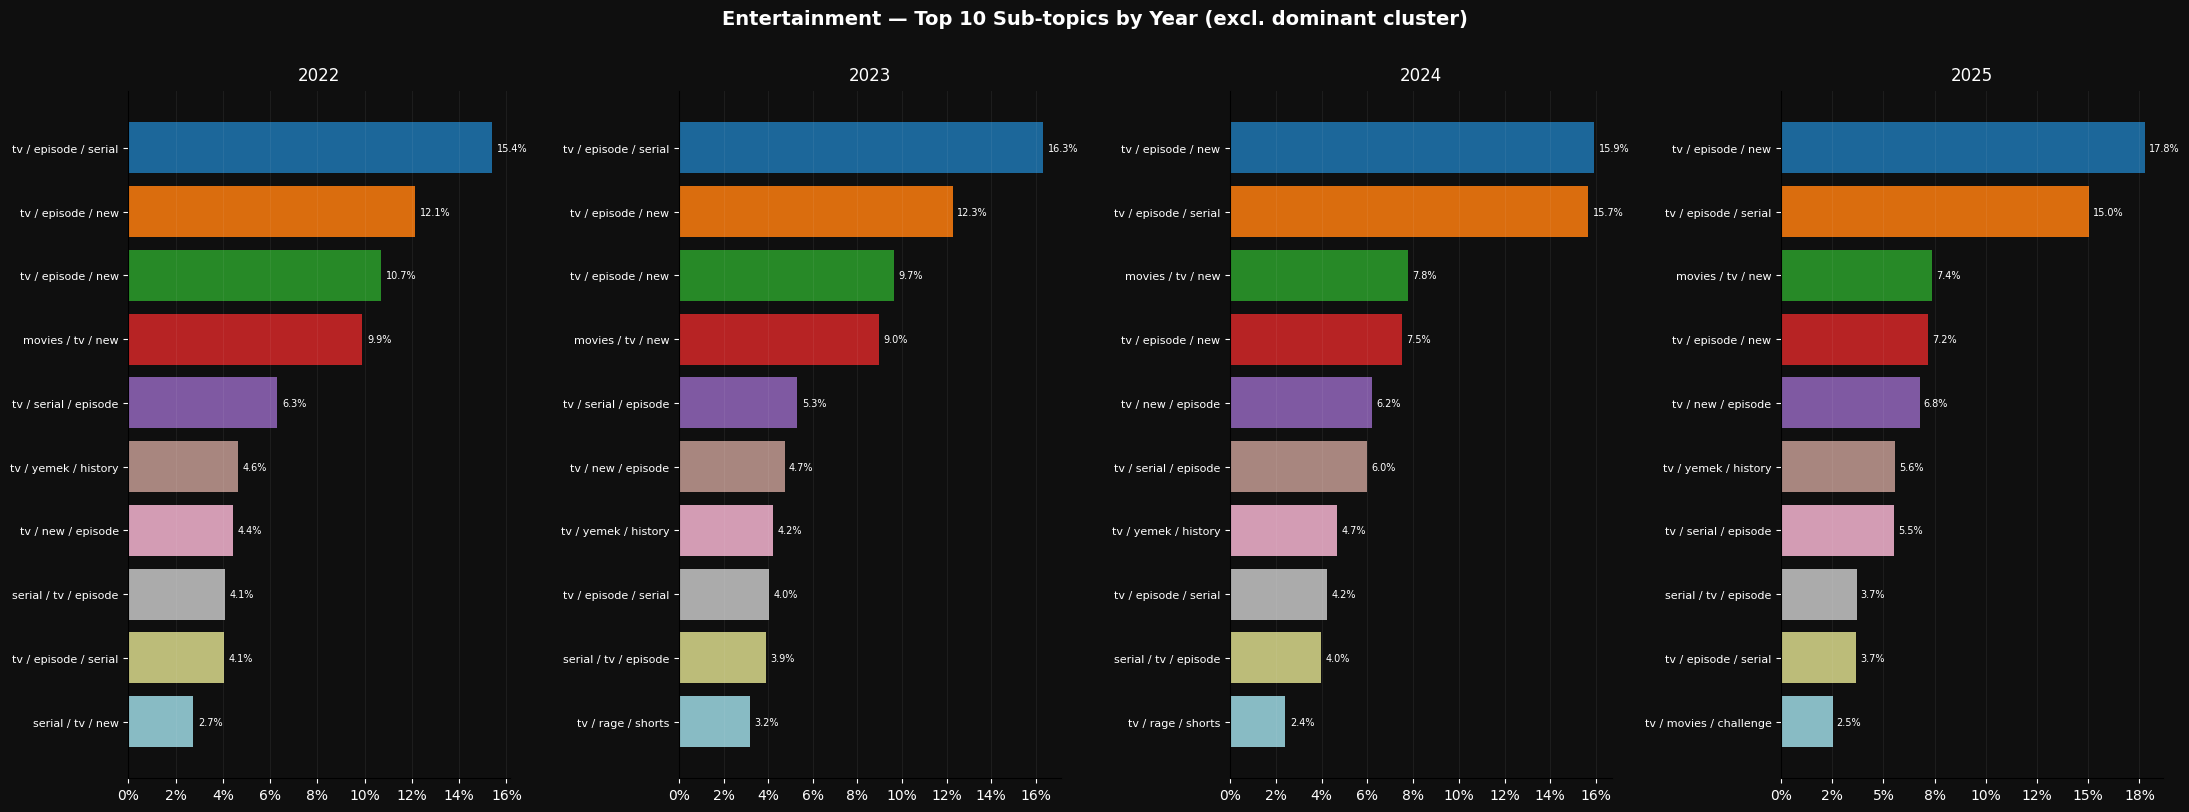

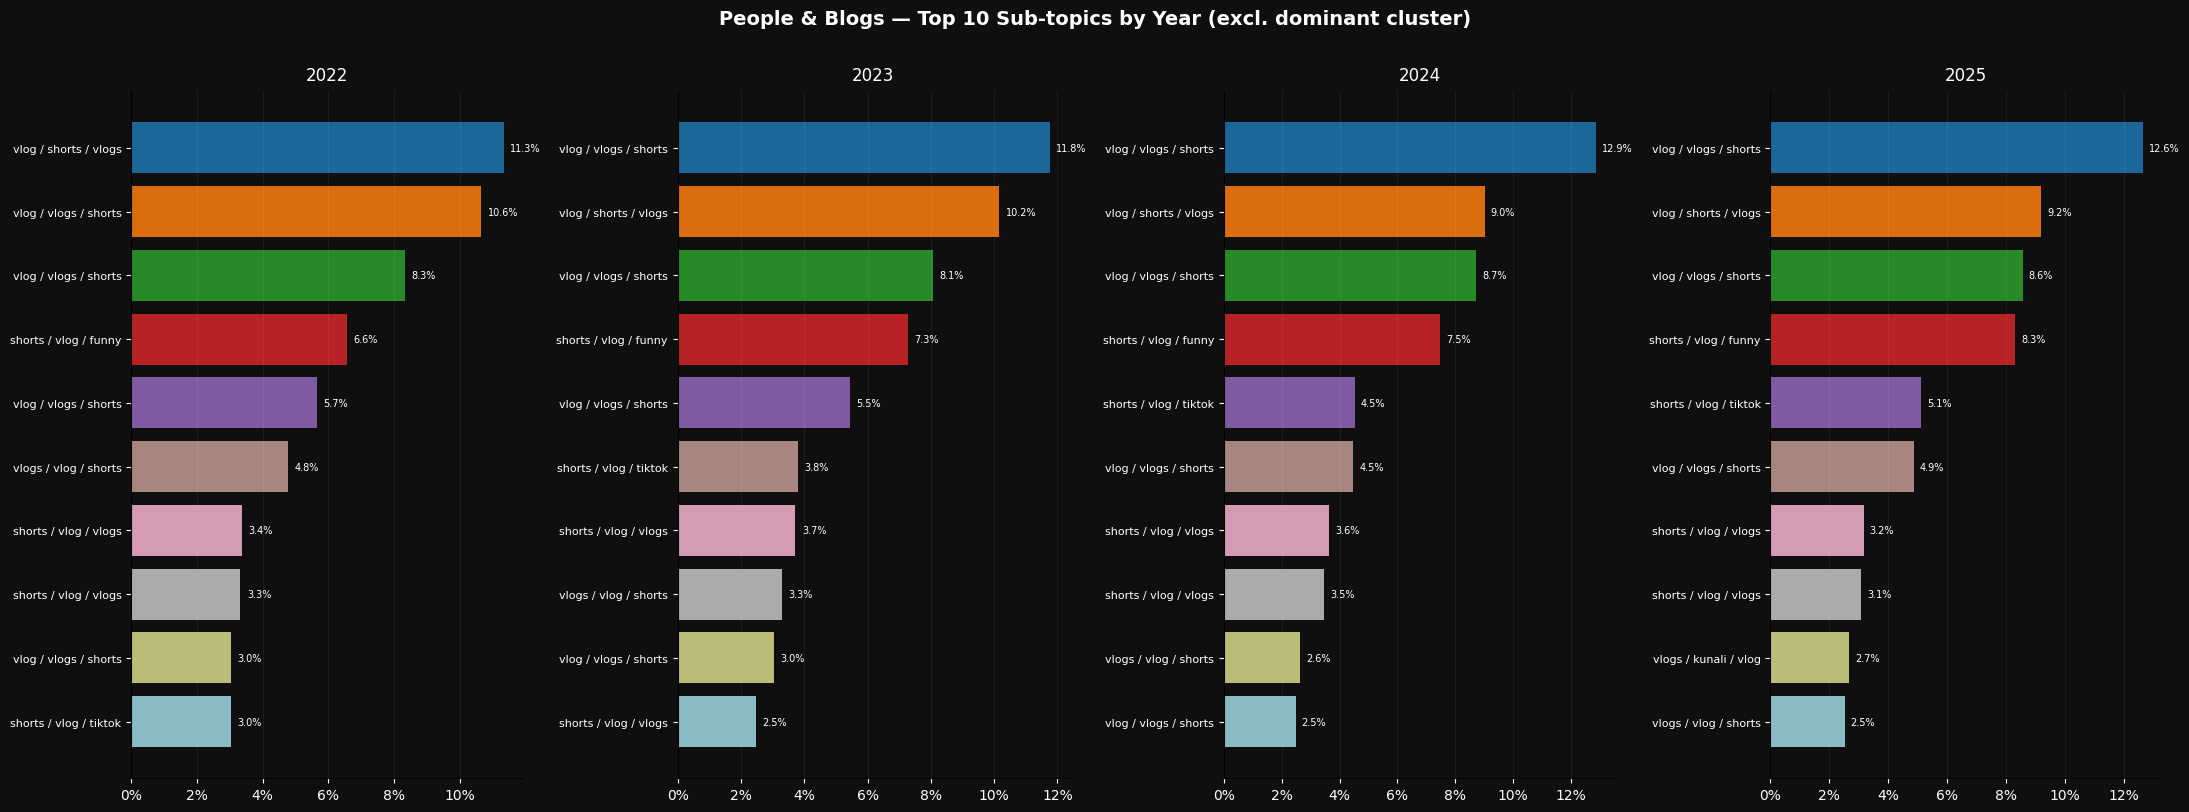

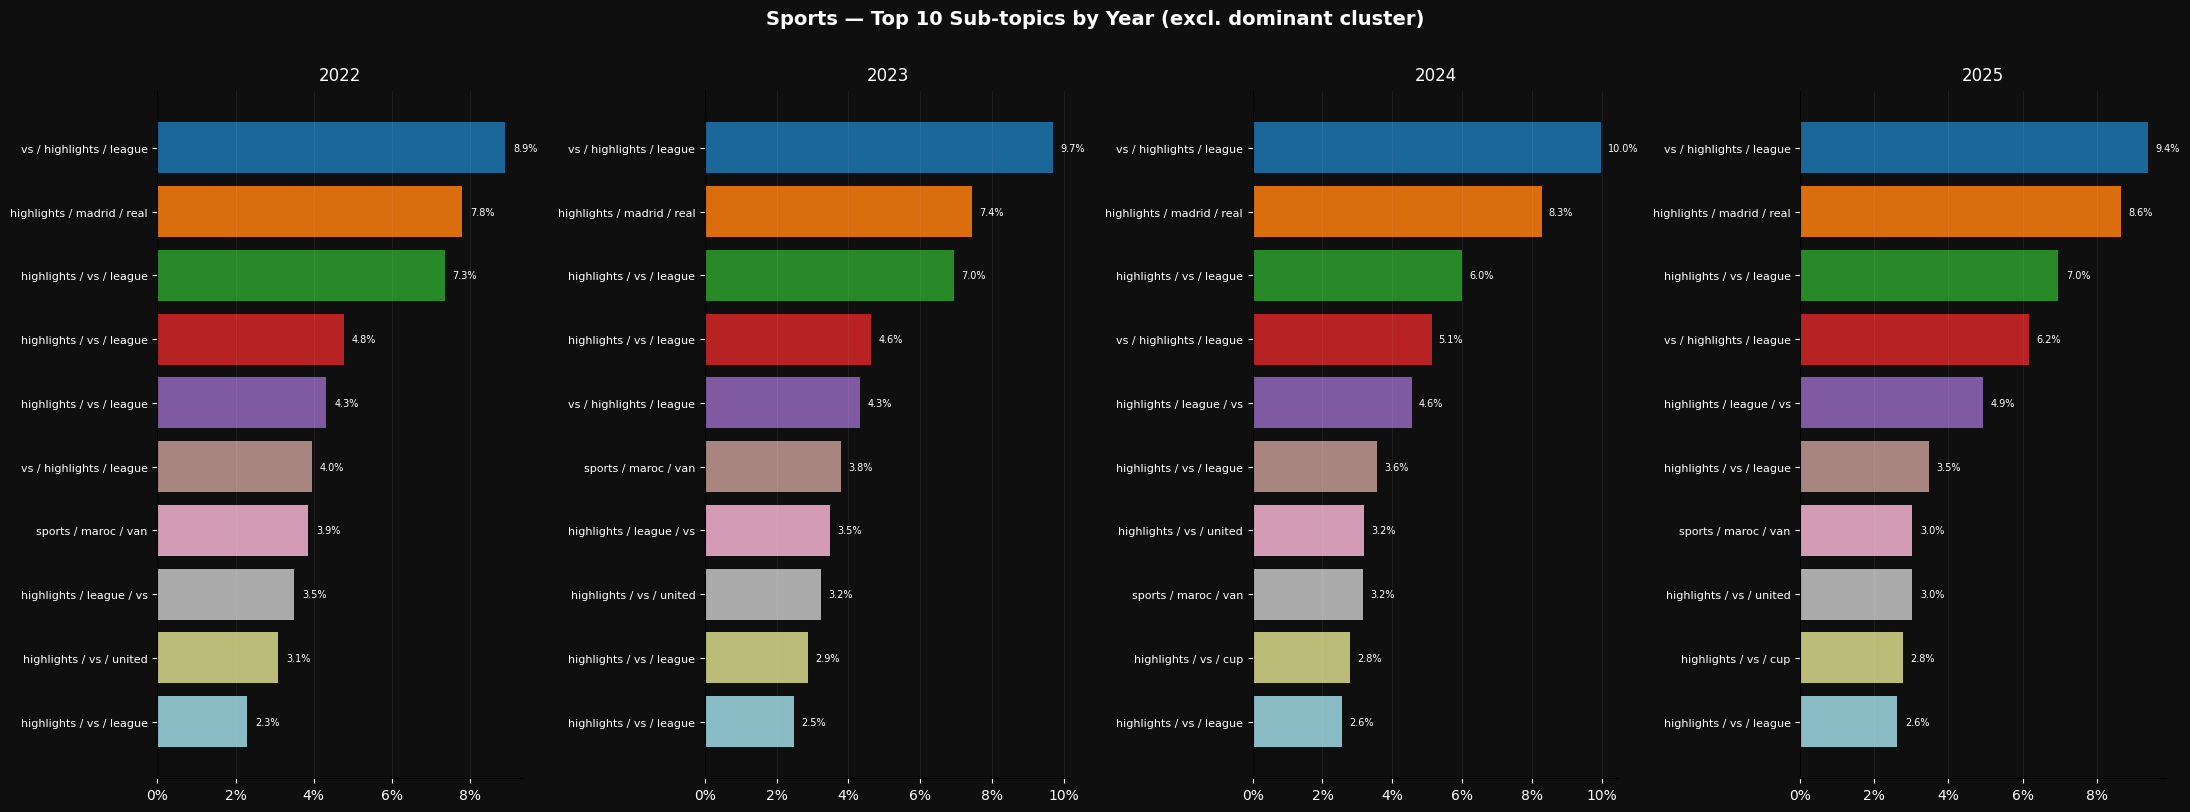

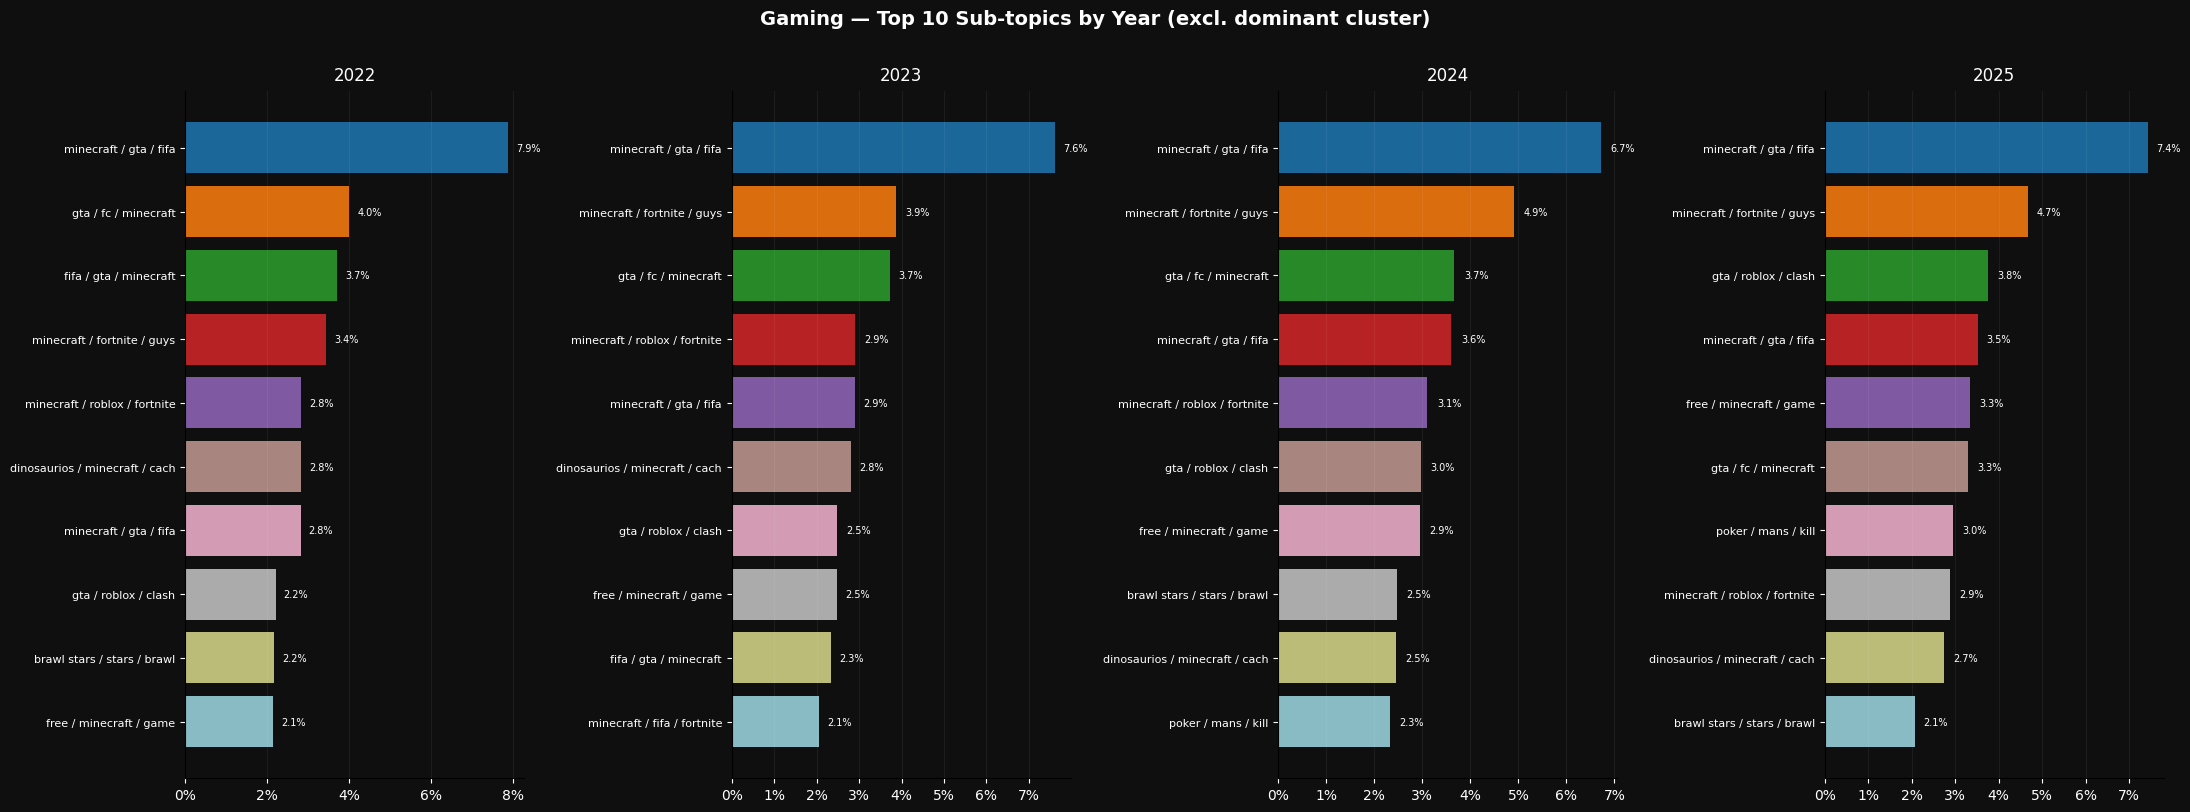

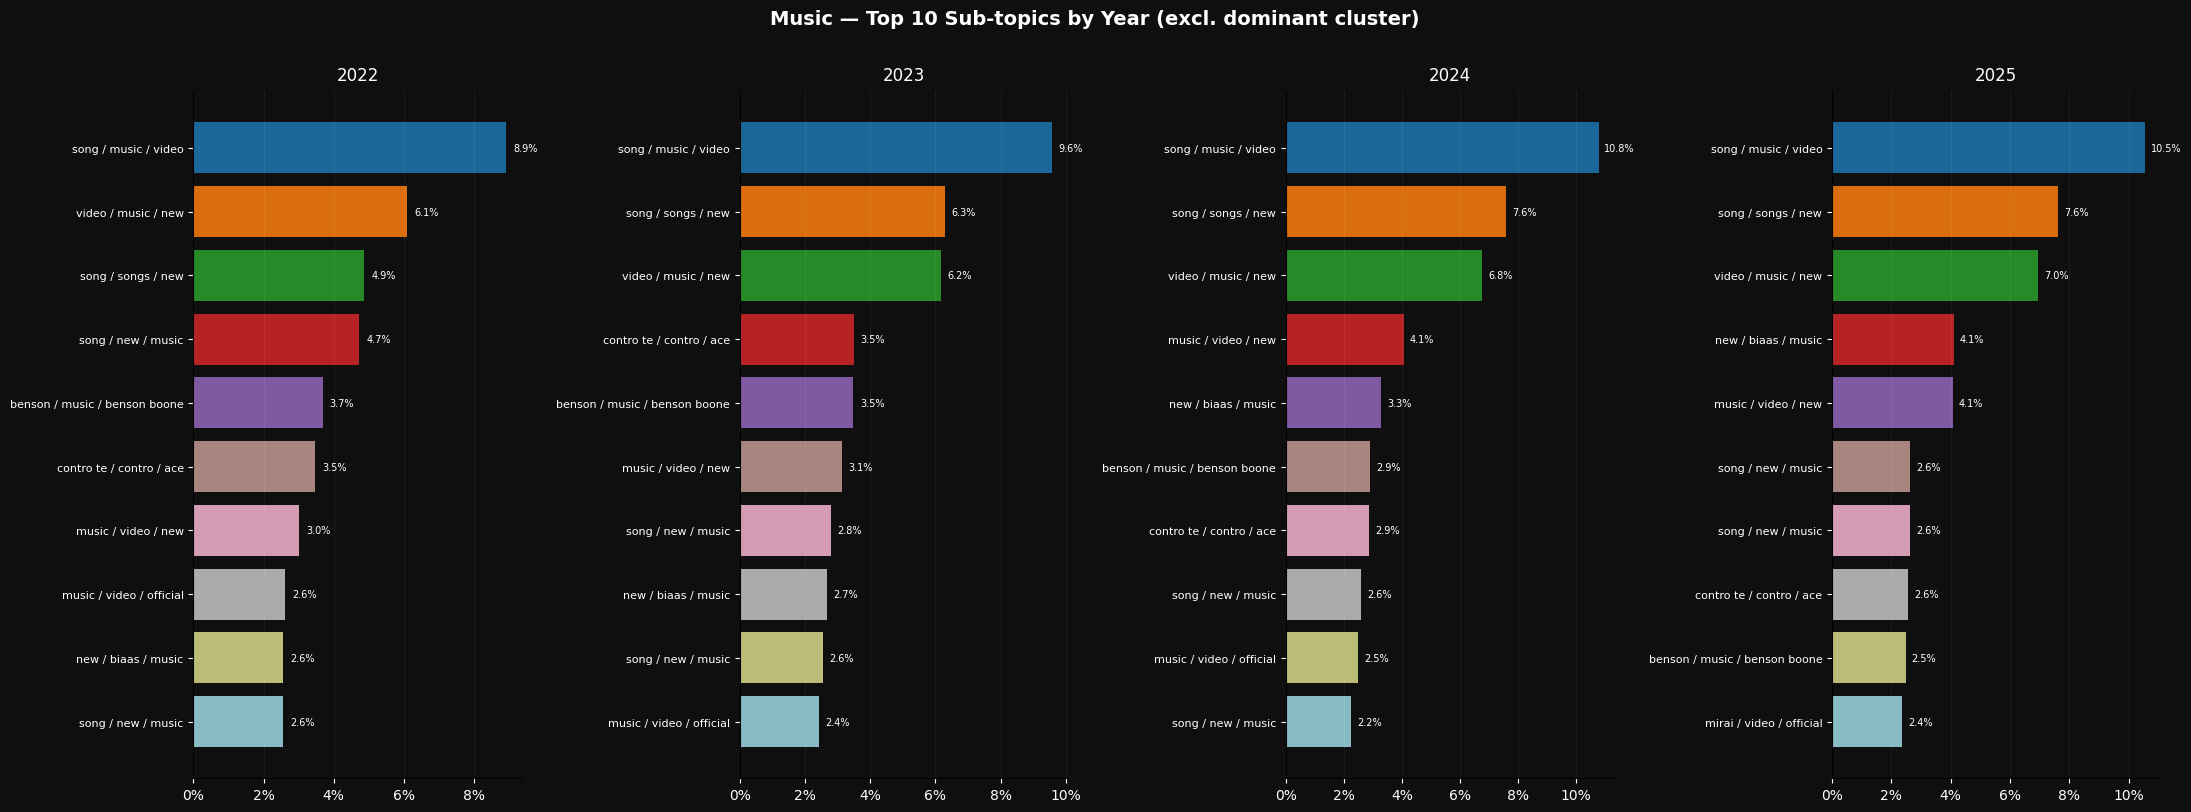

In [7]:
# subtopic distribution by year — horizontal bar charts per category
def plot_top_subtopics(category, top_n=10):
    res = all_results[category]
    keywords = res['keywords']
    dfc = res['df'][res['df']['topic_id'] != -1].copy()
    dfc = dfc[dfc['topic_id'] != 0]  # exclude mega-cluster

    years = sorted(dfc['year'].unique())
    fig, axes = plt.subplots(1, len(years), figsize=(22, 8))
    if len(years) == 1:
        axes = [axes]
    fig.suptitle(
        f'{category} — Top {top_n} Sub-topics by Year (excl. dominant cluster)',
        fontsize=14, fontweight='bold', y=1.01
    )
    colors = cm.tab20(np.linspace(0, 1, top_n))

    for i, year in enumerate(years):
        ax = axes[i]
        ydf = dfc[dfc['year'] == year]
        top = ydf['topic_id'].value_counts().head(top_n).reset_index()
        top.columns = ['topic_id', 'count']
        top['pct'] = top['count'] / ydf.shape[0]

        labels = [' / '.join(keywords.get(int(t), [f'T{t}'])[:3])[:30]
                  for t in top['topic_id']]

        bars = ax.barh(range(len(top)), top['pct'].values, color=colors[:len(top)], alpha=0.85)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(str(year), fontsize=12, pad=8)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.invert_yaxis()
        ax.grid(axis='x', color='white', alpha=0.06)

        for bar, val in zip(bars, top['pct'].values):
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.1%}', va='center', fontsize=7, color='white')

    plt.tight_layout()
    plt.show()

for cat in all_results:
    plot_top_subtopics(cat)

## Kaplan-Meier Survival Analysis

Applying survival modelling to trending data — measuring how long content stays on the trending list across different regions and categories.

- **Event**: video exits the trending list
- **Duration**: `trending_duration` (hours between first and last appearance)
- **Censoring**: all videos have confirmed exits, so no censoring needed

Questions:
1. Are survival curves shifting year-over-year?
2. Do certain categories survive longer?
3. Which regions hold trends the longest?

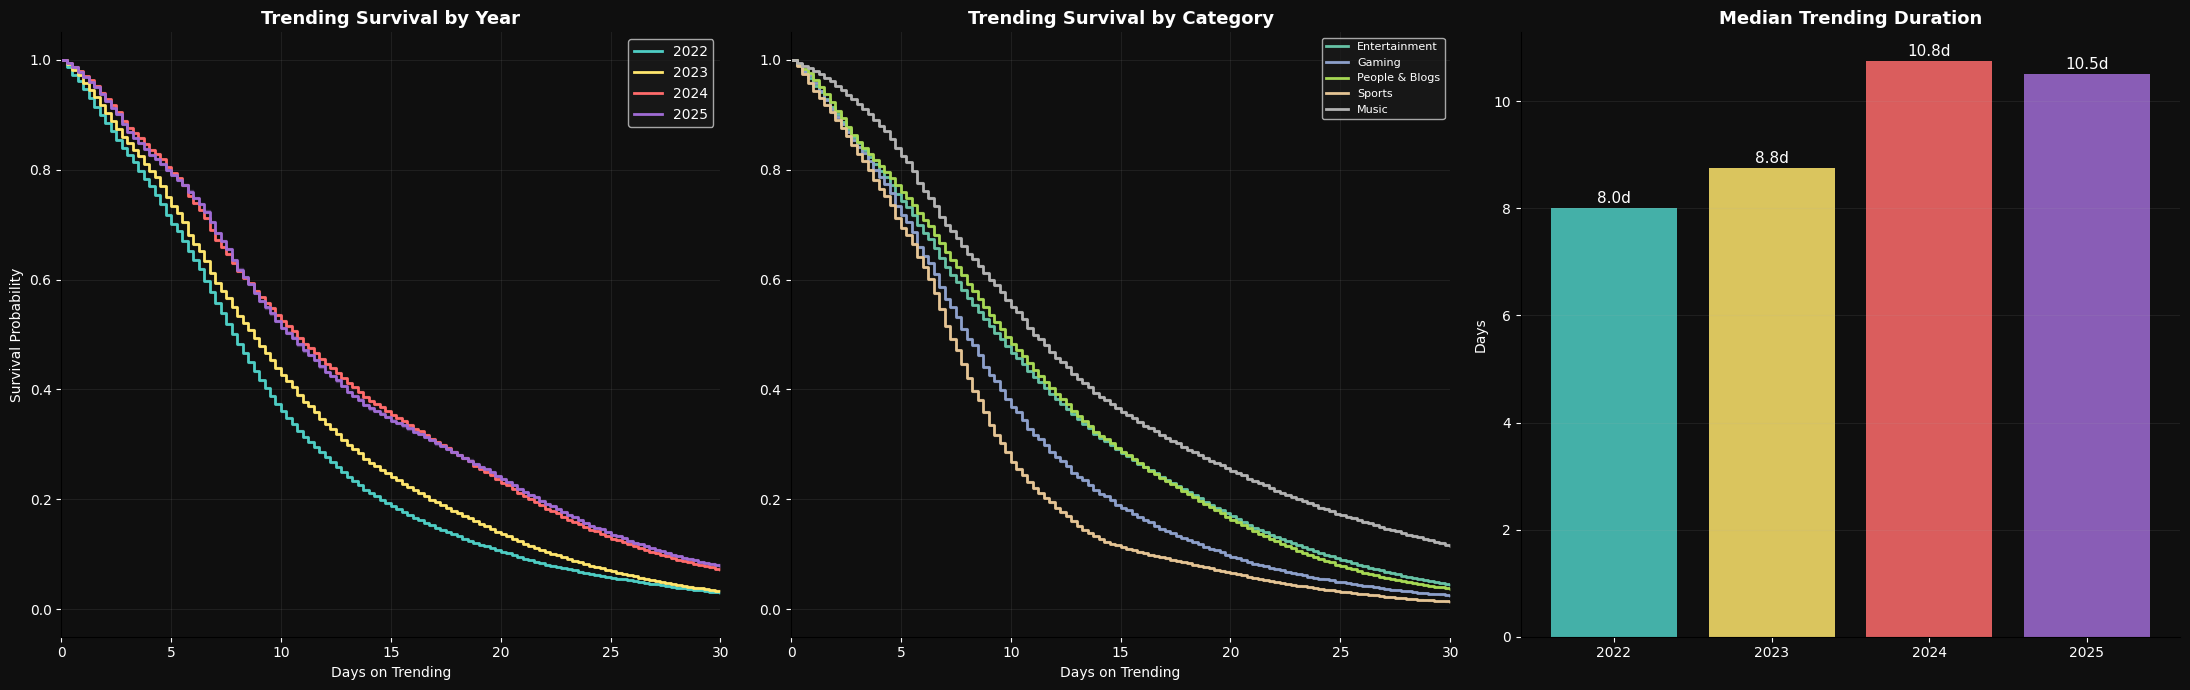


Median trending duration by year:
 year  median_days
 2022         8.00
 2023         8.75
 2024        10.75
 2025        10.50


In [8]:
# --- Kaplan-Meier by year ---
# convert duration from hours to days for readability
surv = entry[entry['trending_duration'].notna() & (entry['trending_duration'] > 0)].copy()
surv['duration_days'] = surv['trending_duration'] / 24.0
surv['event'] = 1  # all fully observed, no censoring

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: KM curves by year
ax = axes[0]
kmf = KaplanMeierFitter()
colors_year = {'2022': '#4ecdc4', '2023': '#ffe66d', '2024': '#ff6b6b', '2025': '#a06cd5'}

for year in sorted(surv['year'].unique()):
    mask = surv['year'] == year
    kmf.fit(surv.loc[mask, 'duration_days'], event_observed=surv.loc[mask, 'event'], label=str(year))
    kmf.plot_survival_function(ax=ax, color=colors_year.get(str(year), 'white'), linewidth=2)

ax.set_title('Trending Survival by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Days on Trending')
ax.set_ylabel('Survival Probability')
ax.set_xlim(0, 30)
ax.legend(fontsize=10)
ax.grid(alpha=0.1)

# Panel 2: KM curves by top-5 category
ax = axes[1]
top5_cats = entry['category_label'].value_counts().head(5).index
cat_colors = cm.Set2(np.linspace(0, 1, 5))

for i, cat in enumerate(top5_cats):
    mask = surv['category_label'] == cat
    if mask.sum() < 100:
        continue
    kmf.fit(surv.loc[mask, 'duration_days'], event_observed=surv.loc[mask, 'event'], label=cat)
    kmf.plot_survival_function(ax=ax, color=cat_colors[i], linewidth=2)

ax.set_title('Trending Survival by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Days on Trending')
ax.set_ylabel('')
ax.set_xlim(0, 30)
ax.legend(fontsize=8)
ax.grid(alpha=0.1)

# Panel 3: median survival by year
ax = axes[2]
medians = []
for year in sorted(surv['year'].unique()):
    mask = surv['year'] == year
    kmf.fit(surv.loc[mask, 'duration_days'], event_observed=surv.loc[mask, 'event'])
    medians.append({'year': year, 'median_days': kmf.median_survival_time_})

med_df = pd.DataFrame(medians)
bars = ax.bar(med_df['year'].astype(str), med_df['median_days'],
              color=['#4ecdc4', '#ffe66d', '#ff6b6b', '#a06cd5'], alpha=0.85)
for bar, val in zip(bars, med_df['median_days']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}d', ha='center', fontsize=11, color='white')
ax.set_title('Median Trending Duration', fontsize=13, fontweight='bold')
ax.set_ylabel('Days')
ax.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

print("\nMedian trending duration by year:")
print(med_df.to_string(index=False))

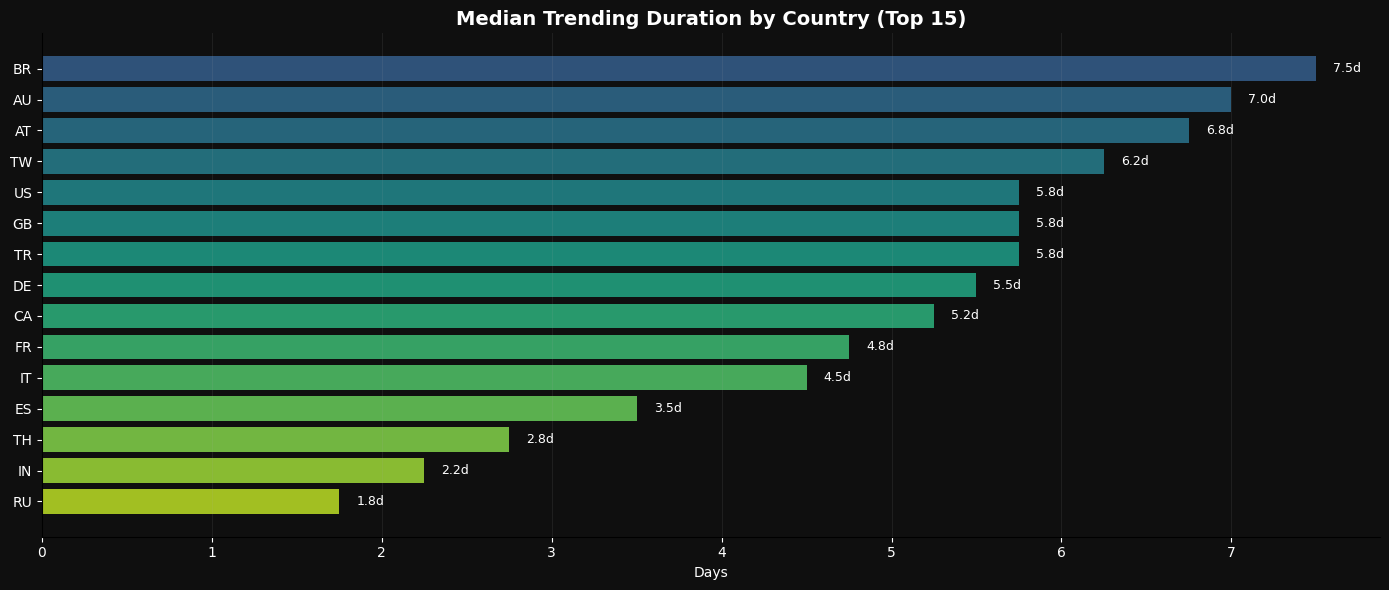


Log-rank test (2022 vs 2025): p = 0.000000
Statistically significant difference


In [9]:
# --- Survival by region (top 15 countries by video count) ---
top_regions = entry['region_code'].value_counts().head(15).index.tolist()
surv_region = surv[surv['region_code'].isin(top_regions)]

region_medians = []
for rc in top_regions:
    mask = surv_region['region_code'] == rc
    kmf.fit(surv_region.loc[mask, 'duration_days'], event_observed=surv_region.loc[mask, 'event'])
    region_medians.append({'region': rc, 'median_days': kmf.median_survival_time_,
                           'count': mask.sum()})

rm_df = pd.DataFrame(region_medians).sort_values('median_days', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = cm.viridis(np.linspace(0.3, 0.9, len(rm_df)))
bars = ax.barh(rm_df['region'], rm_df['median_days'], color=colors_bar, alpha=0.85)

for bar, val in zip(bars, rm_df['median_days']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}d', va='center', fontsize=9, color='white')

ax.set_title('Median Trending Duration by Country (Top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Days')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.1)
plt.tight_layout()
plt.show()

# log-rank test: is 2022 different from 2025?
s22 = surv[surv['year'] == 2022]
s25 = surv[surv['year'] == 2025]
if len(s22) > 0 and len(s25) > 0:
    result = logrank_test(s22['duration_days'], s25['duration_days'],
                          event_observed_A=s22['event'], event_observed_B=s25['event'])
    print(f"\nLog-rank test (2022 vs 2025): p = {result.p_value:.6f}")
    print("Statistically significant difference" if result.p_value < 0.05 else "No significant difference")

## DBSCAN Country Clustering — Attention Archetypes

For each country we build a feature vector from:
- **Category distribution**: % of trending videos in each YouTube category
- **Engagement profile**: mean engagement depth, mean view count
- **Temporal profile**: mean trending duration, mean time-to-trend
- **Diversity**: number of distinct categories represented

DBSCAN finds natural groupings without requiring us to specify the number of clusters. Countries in the same cluster share similar "attention profiles."

Country feature matrix: (104, 21)
Countries: 104
Features: 21


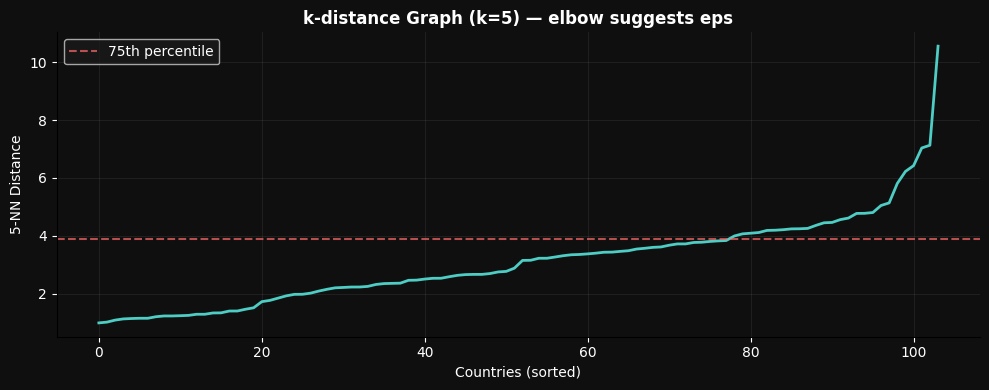


eps sweep:
  p25: eps=2.01  → 6 clusters, 55 noise
  p35: eps=2.36  → 6 clusters, 47 noise
  p50: eps=3.02  → 5 clusters, 34 noise
  p65: eps=3.57  → 4 clusters, 13 noise
  p75: eps=3.88  → 1 clusters, 9 noise

Using eps = 2.36


In [10]:
# --- build country feature vectors ---
# category distribution per country
cat_dist = (
    entry.groupby(['region_code', 'category_label'])
    .size()
    .reset_index(name='count')
)
cat_dist['total'] = cat_dist.groupby('region_code')['count'].transform('sum')
cat_dist['share'] = cat_dist['count'] / cat_dist['total']

cat_pivot = cat_dist.pivot_table(
    index='region_code', columns='category_label',
    values='share', fill_value=0
)

# scalar features per country
country_stats = entry.groupby('region_code').agg(
    mean_duration=('trending_duration', 'mean'),
    mean_ttt=('time_to_trend', 'mean'),
    mean_engagement=('engagement_depth', 'mean'),
    mean_views=('view_count', 'mean'),
    n_categories=('category_label', 'nunique'),
    n_videos=('video_id', 'nunique'),
).fillna(0)

# combine into a single feature matrix
country_features = cat_pivot.join(country_stats, how='inner')
print(f"Country feature matrix: {country_features.shape}")
print(f"Countries: {country_features.shape[0]}")
print(f"Features: {country_features.shape[1]}")

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features)

# DBSCAN — eps tuned via nearest-neighbor distance
nn = NearestNeighbors(n_neighbors=5, metric='euclidean')
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='#4ecdc4', linewidth=2)
ax.set_title('k-distance Graph (k=5) — elbow suggests eps', fontsize=12, fontweight='bold')
ax.set_xlabel('Countries (sorted)')
ax.set_ylabel('5-NN Distance')
ax.axhline(y=np.percentile(k_dist, 75), color='#ff6b6b', linestyle='--', alpha=0.7, label='75th percentile')
ax.legend()
ax.grid(alpha=0.1)
plt.tight_layout()
plt.show()

# pick eps near the elbow — try multiple and show cluster counts
print("\neps sweep:")
for pct in [25, 35, 50, 65, 75]:
    trial_eps = np.percentile(k_dist, pct)
    trial_labels = DBSCAN(eps=trial_eps, min_samples=3).fit_predict(X_scaled)
    nc = len(set(trial_labels)) - (1 if -1 in trial_labels else 0)
    nn_ct = (trial_labels == -1).sum()
    print(f"  p{pct}: eps={trial_eps:.2f}  → {nc} clusters, {nn_ct} noise")

# use 35th percentile for more granular archetypes
eps_val = np.percentile(k_dist, 35)
print(f"\nUsing eps = {eps_val:.2f}")

In [11]:
# --- run DBSCAN ---
db = DBSCAN(eps=eps_val, min_samples=3, metric='euclidean')
labels = db.fit_predict(X_scaled)

country_features['cluster'] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise countries: {n_noise}")

# show cluster membership
for cl in sorted(set(labels)):
    members = country_features[country_features['cluster'] == cl].index.tolist()
    label = f"Cluster {cl}" if cl != -1 else "Noise"
    print(f"\n{label} ({len(members)} countries):")
    print(f"  {', '.join(members)}")

# cluster profiles — mean features
print("\n\nCluster profiles (mean values):")
profile_cols = ['mean_duration', 'mean_ttt', 'mean_engagement', 'mean_views', 'n_categories']
cluster_profiles = country_features.groupby('cluster')[profile_cols].mean()
print(cluster_profiles.round(3).to_string())

Clusters found: 6
Noise countries: 47

Noise (47 countries):
  AZ, BR, BY, CY, EE, ES, FI, GE, GH, HK, HU, ID, IN, IS, IT, JM, JP, KE, KR, KZ, LK, LT, LU, LV, MT, MY, NG, NP, PH, PK, PL, PR, PT, RO, RU, SG, SN, SV, TH, TR, TW, TZ, UA, UG, VN, ZA, ZW

Cluster 0 (15 countries):
  AE, BH, DZ, EG, IQ, JO, KW, LB, LY, MA, OM, QA, SA, TN, YE

Cluster 1 (9 countries):
  AR, CR, DO, GT, HN, MX, NI, PA, UY

Cluster 2 (7 countries):
  AT, AU, CA, DE, FR, GB, US

Cluster 3 (15 countries):
  BA, BE, BG, CH, CZ, GR, HR, IL, LI, ME, MK, NL, RS, SI, SK

Cluster 4 (6 countries):
  BO, CL, CO, EC, PE, PY

Cluster 5 (5 countries):
  DK, IE, NO, NZ, SE


Cluster profiles (mean values):
         mean_duration  mean_ttt  mean_engagement   mean_views  n_categories
cluster                                                                     
-1             305.863    58.183            0.003  3662561.514        14.787
 0             372.253    22.664            0.006  1270783.136        15.000
 1             3

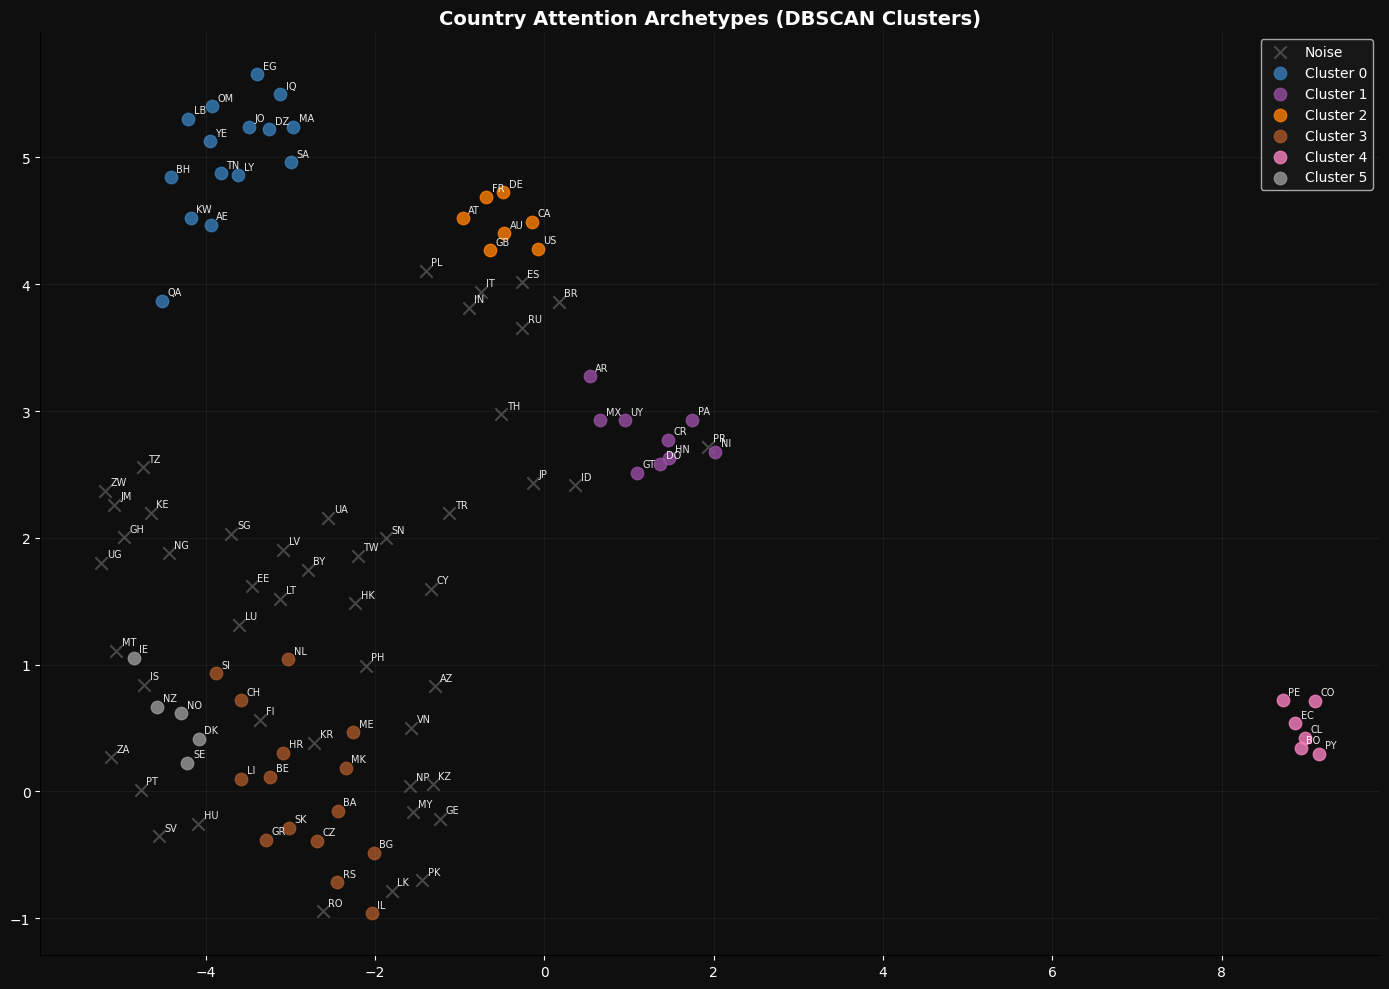

In [12]:
# --- visualize clusters with UMAP 2D projection ---
from umap import UMAP as UMAP2D

reducer = UMAP2D(n_components=2, random_state=42, n_neighbors=10, min_dist=0.3)
coords = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(14, 10))
unique_labels = sorted(set(labels))
cmap = cm.Set1(np.linspace(0, 1, max(n_clusters + 1, 2)))

for i, cl in enumerate(unique_labels):
    mask = labels == cl
    color = '#555555' if cl == -1 else cmap[i % len(cmap)]
    marker = 'x' if cl == -1 else 'o'
    label = 'Noise' if cl == -1 else f'Cluster {cl}'
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[color], marker=marker, s=80, label=label, alpha=0.8)

# annotate country codes
for j, rc in enumerate(country_features.index):
    ax.annotate(rc, (coords[j, 0], coords[j, 1]),
                fontsize=7, color='white', alpha=0.9,
                textcoords="offset points", xytext=(4, 4))

ax.set_title('Country Attention Archetypes (DBSCAN Clusters)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.08)
plt.tight_layout()
plt.show()

## Convergence Metrics

Testing the core hypothesis: *Are YouTube trending lists converging over time?*

1. **Shannon entropy** (category-level) — declining entropy = fewer themes dominating
2. **Topic variety index** — distinct categories active per year
3. **Top-N concentration** — share of trending videos held by the top 3 categories
4. **Cross-country cosine similarity** — are different countries' category mixes becoming more alike?
5. **Trend churn rate** — how quickly are themes rotating in and out?

In [13]:
# --- 1. Shannon entropy (category-level, per year) ---
e = entry[entry['category_id'].notna()].copy()
e['category_id'] = e['category_id'].astype(int)

entropy_by_year = (
    e.groupby('year')['category_id']
    .apply(shannon_entropy)
    .reset_index()
    .rename(columns={'category_id': 'entropy'})
)
print("Shannon entropy of category distribution by year:")
print(entropy_by_year.to_string(index=False))

# --- 2. Topic variety (distinct categories per year) ---
variety = e.groupby('year')['category_id'].nunique().reset_index()
variety.columns = ['year', 'distinct_categories']
print("\nTopic variety by year:")
print(variety.to_string(index=False))

# --- 3. Top-3 concentration ---
cat_share = e.groupby(['year', 'category_id']).size().reset_index(name='count')
cat_share['total'] = cat_share.groupby('year')['count'].transform('sum')
cat_share['share'] = cat_share['count'] / cat_share['total']

top3 = (
    cat_share.groupby('year')
    .apply(lambda x: x.nlargest(3, 'share')['share'].sum())
    .reset_index()
    .rename(columns={0: 'top3_share'})
)
print("\nTop-3 category concentration:")
print(top3.to_string(index=False))

# --- 4. Cross-country cosine similarity ---
cat_share_country = (
    e.groupby(['year', 'region_code', 'category_label'])
    .size().reset_index(name='count')
)
cat_share_country['total'] = cat_share_country.groupby(['year', 'region_code'])['count'].transform('sum')
cat_share_country['share'] = cat_share_country['count'] / cat_share_country['total']

pivot = cat_share_country.pivot_table(
    index=['region_code', 'year'], columns='category_label',
    values='share', fill_value=0
).reset_index()

sim_records = []
for year in sorted(pivot['year'].unique()):
    ydata = pivot[pivot['year'] == year].drop(columns=['region_code', 'year'])
    sim = cosine_similarity(ydata)
    n = sim.shape[0]
    upper = sim[np.triu_indices(n, k=1)]
    sim_records.append({
        'year': year,
        'mean_cosine_sim': upper.mean(),
        'std': upper.std()
    })

sim_df = pd.DataFrame(sim_records)
print("\nCross-country cosine similarity by year:")
print(sim_df.to_string(index=False))

Shannon entropy of category distribution by year:
 year  entropy
 2022 3.139518
 2023 3.121584
 2024 3.120103
 2025 3.116087

Topic variety by year:
 year  distinct_categories
 2022                   15
 2023                   15
 2024                   15
 2025                   15

Top-3 category concentration:
 year  top3_share
 2022    0.533521
 2023    0.540564
 2024    0.565611
 2025    0.565899

Cross-country cosine similarity by year:
 year  mean_cosine_sim      std
 2022         0.848988 0.106350
 2023         0.856027 0.107132
 2024         0.866867 0.087114
 2025         0.853398 0.096538


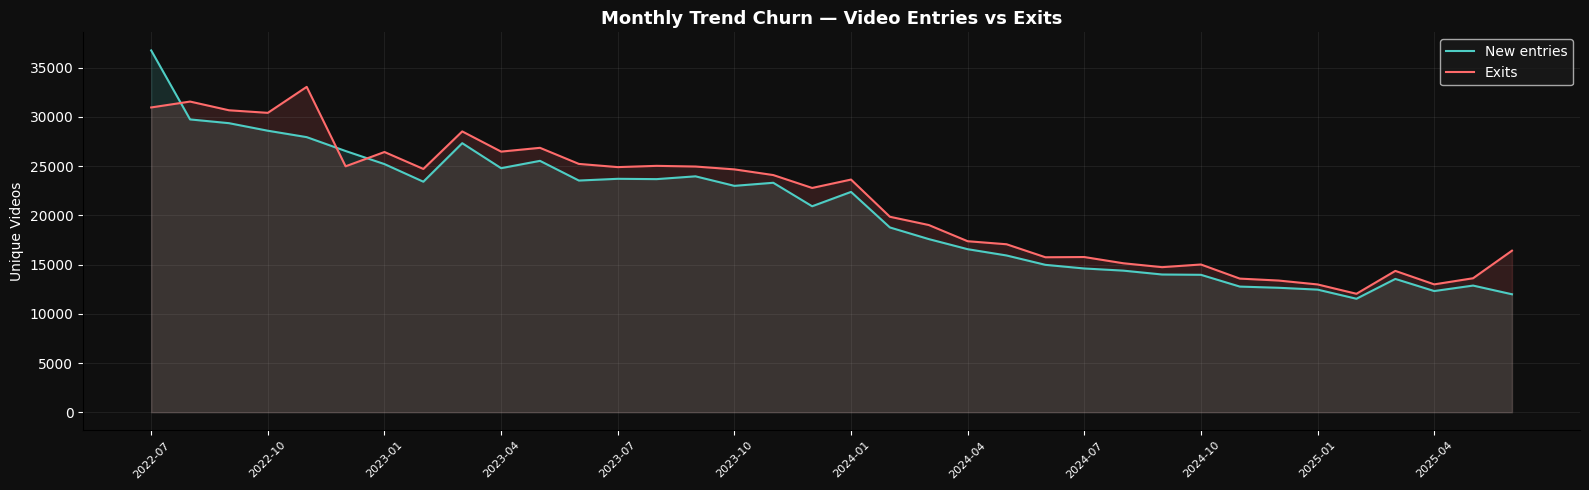


Annual churn summary:
      new_videos  exited_videos  turnover_ratio
year                                           
2022      178981         181682        2.015091
2023      288474         304744        2.056400
2024      188591         200335        2.062272
2025       74707          82404        2.103029


In [14]:
# --- 5. Trend churn rate ---
# how many unique video_ids enter trending per month vs leave?
monthly_entry = (
    entry.groupby('month')['video_id']
    .nunique()
    .reset_index()
    .rename(columns={'video_id': 'new_videos'})
)

# exit snapshots
exits = df[df['snapshot_type'] == 'exit'].copy()
exits['month'] = pd.to_datetime(exits['collection_date']).dt.to_period('M')
monthly_exit = (
    exits.groupby('month')['video_id']
    .nunique()
    .reset_index()
    .rename(columns={'video_id': 'exited_videos'})
)

churn = monthly_entry.merge(monthly_exit, on='month', how='outer').fillna(0)
churn['net_turnover'] = churn['new_videos'] + churn['exited_videos']
churn['month_str'] = churn['month'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(churn['month_str'], churn['new_videos'], color='#4ecdc4', linewidth=1.5, label='New entries')
ax.plot(churn['month_str'], churn['exited_videos'], color='#ff6b6b', linewidth=1.5, label='Exits')
ax.fill_between(churn['month_str'], churn['new_videos'], alpha=0.15, color='#4ecdc4')
ax.fill_between(churn['month_str'], churn['exited_videos'], alpha=0.15, color='#ff6b6b')

# show every 3rd label to avoid crowding
ticks = list(range(0, len(churn), 3))
ax.set_xticks(ticks)
ax.set_xticklabels([churn['month_str'].iloc[t] for t in ticks], rotation=45, fontsize=8)
ax.set_title('Monthly Trend Churn — Video Entries vs Exits', fontsize=13, fontweight='bold')
ax.set_ylabel('Unique Videos')
ax.legend(fontsize=10)
ax.grid(alpha=0.1)
plt.tight_layout()
plt.show()

# churn rate = turnover / active pool
print("\nAnnual churn summary:")
churn['year'] = churn['month'].apply(lambda x: x.year)
annual_churn = churn.groupby('year')[['new_videos', 'exited_videos']].sum()
annual_churn['turnover_ratio'] = (annual_churn['new_videos'] + annual_churn['exited_videos']) / annual_churn['new_videos']
print(annual_churn.to_string())

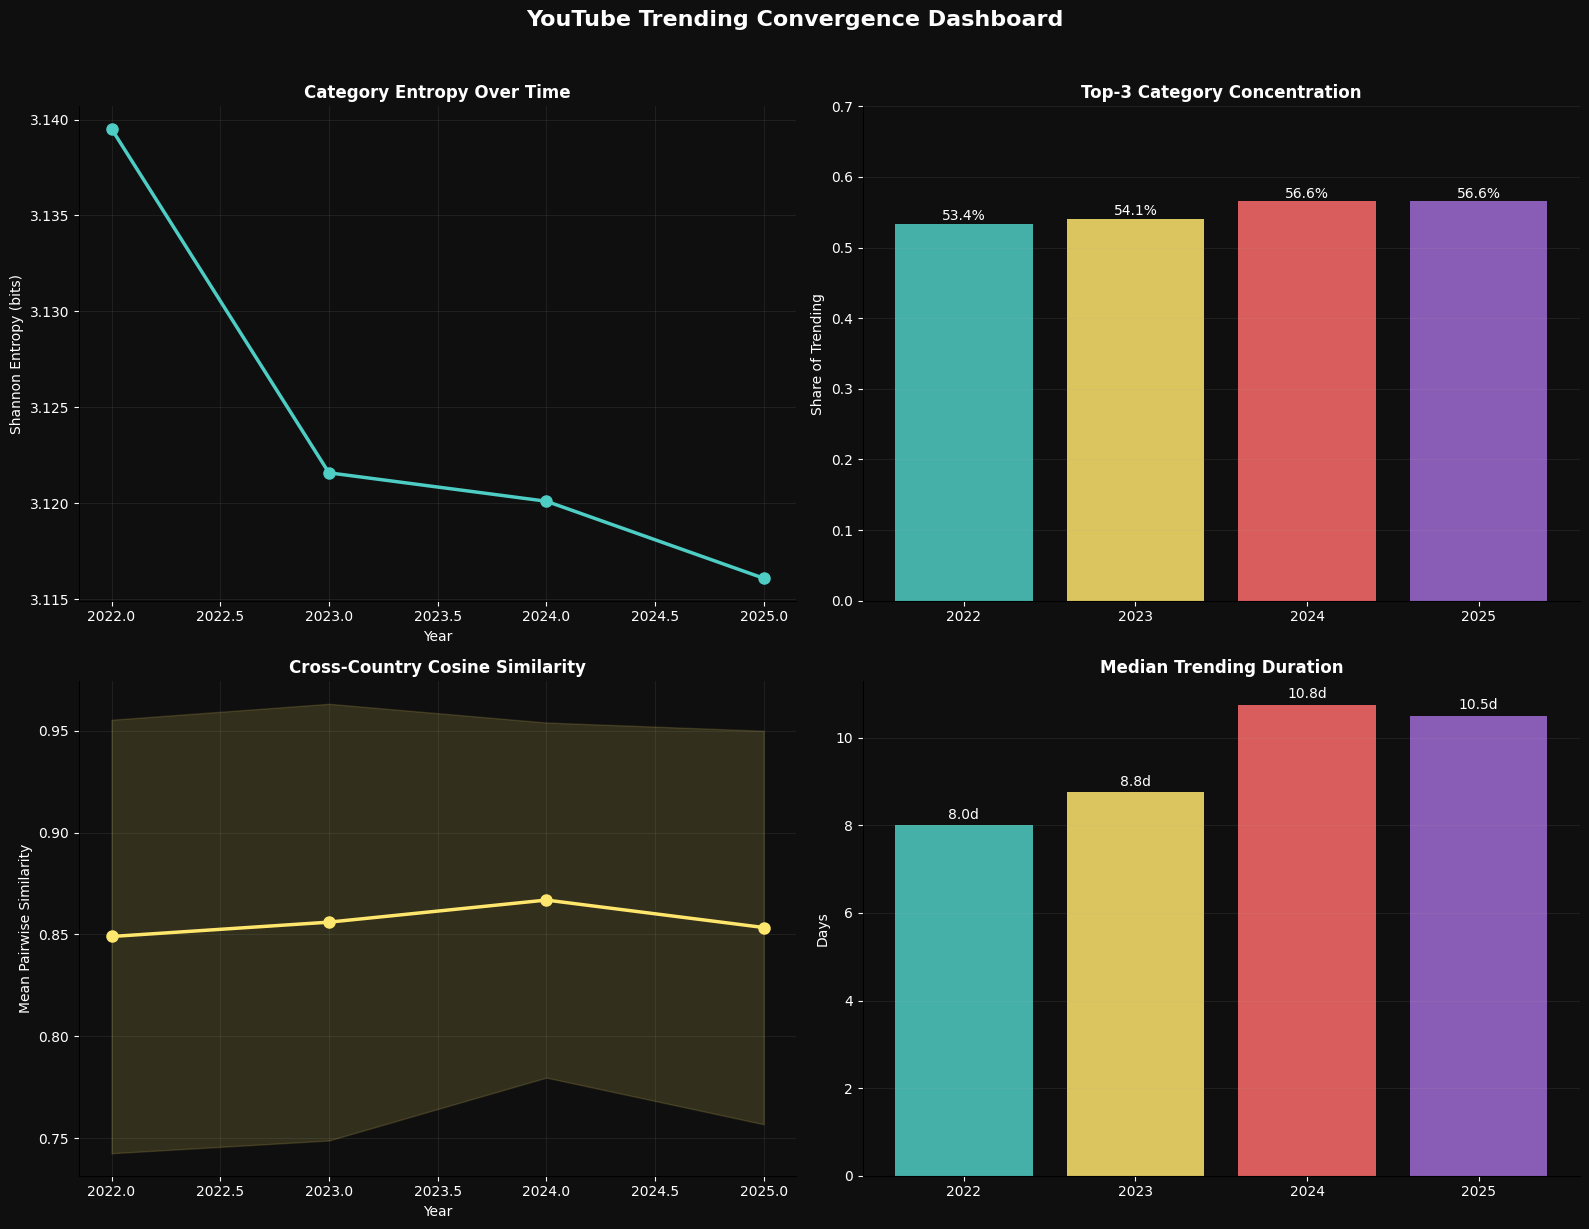

In [15]:
# --- Summary dashboard: 4 convergence metrics on one figure ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Shannon entropy over time
ax = axes[0, 0]
ax.plot(entropy_by_year['year'], entropy_by_year['entropy'], 'o-',
        color='#4ecdc4', linewidth=2.5, markersize=8)
ax.set_title('Category Entropy Over Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Shannon Entropy (bits)')
ax.set_xlabel('Year')
ax.grid(alpha=0.1)

# (b) Top-3 concentration
ax = axes[0, 1]
ax.bar(top3['year'].astype(str), top3['top3_share'],
       color=['#4ecdc4', '#ffe66d', '#ff6b6b', '#a06cd5'], alpha=0.85)
for i, (_, row) in enumerate(top3.iterrows()):
    ax.text(i, row['top3_share'] + 0.005, f"{row['top3_share']:.1%}",
            ha='center', fontsize=10, color='white')
ax.set_title('Top-3 Category Concentration', fontsize=12, fontweight='bold')
ax.set_ylabel('Share of Trending')
ax.set_ylim(0, 0.7)
ax.grid(axis='y', alpha=0.1)

# (c) Cross-country similarity
ax = axes[1, 0]
ax.plot(sim_df['year'], sim_df['mean_cosine_sim'], 'o-',
        color='#ffe66d', linewidth=2.5, markersize=8)
ax.fill_between(sim_df['year'],
                sim_df['mean_cosine_sim'] - sim_df['std'],
                sim_df['mean_cosine_sim'] + sim_df['std'],
                alpha=0.15, color='#ffe66d')
ax.set_title('Cross-Country Cosine Similarity', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Pairwise Similarity')
ax.set_xlabel('Year')
ax.grid(alpha=0.1)

# (d) Median trending survival by year
ax = axes[1, 1]
ax.bar(med_df['year'].astype(str), med_df['median_days'],
       color=['#4ecdc4', '#ffe66d', '#ff6b6b', '#a06cd5'], alpha=0.85)
for i, (_, row) in enumerate(med_df.iterrows()):
    ax.text(i, row['median_days'] + 0.15, f"{row['median_days']:.1f}d",
            ha='center', fontsize=10, color='white')
ax.set_title('Median Trending Duration', fontsize=12, fontweight='bold')
ax.set_ylabel('Days')
ax.grid(axis='y', alpha=0.1)

fig.suptitle('YouTube Trending Convergence Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Category-Level Streamgraph

How the share of each category in the trending ecosystem evolves month-by-month across the full 3-year window.

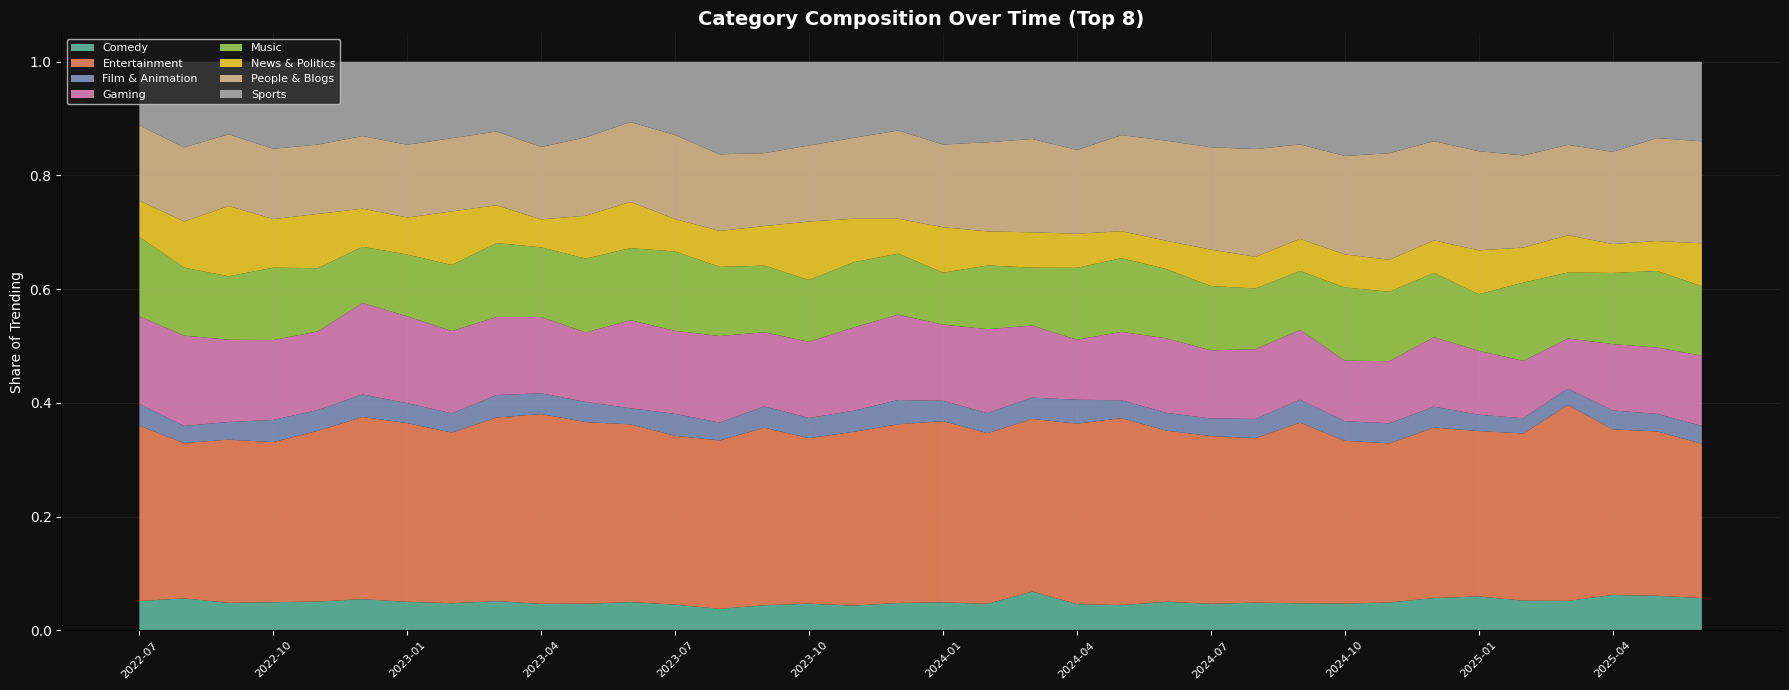

In [16]:
# --- Streamgraph / ThemeRiver ---
e_monthly = e.copy()
e_monthly['month'] = e_monthly['first_seen'].dt.to_period('M')

top_cats = e_monthly['category_label'].value_counts().head(8).index.tolist()
monthly_cat = (
    e_monthly[e_monthly['category_label'].isin(top_cats)]
    .groupby(['month', 'category_label'])
    .size()
    .reset_index(name='count')
)
monthly_cat['total'] = monthly_cat.groupby('month')['count'].transform('sum')
monthly_cat['share'] = monthly_cat['count'] / monthly_cat['total']

stream_pivot = monthly_cat.pivot_table(
    index='month', columns='category_label', values='share', fill_value=0
)
stream_pivot = stream_pivot.sort_index()

fig, ax = plt.subplots(figsize=(18, 7))
months_str = [str(m) for m in stream_pivot.index]
x = np.arange(len(months_str))

colors_stream = cm.Set2(np.linspace(0, 1, len(stream_pivot.columns)))
ax.stackplot(x, *[stream_pivot[col].values for col in stream_pivot.columns],
             labels=stream_pivot.columns, colors=colors_stream, alpha=0.85)

tick_idx = list(range(0, len(months_str), 3))
ax.set_xticks(tick_idx)
ax.set_xticklabels([months_str[i] for i in tick_idx], rotation=45, fontsize=8)
ax.set_title('Category Composition Over Time (Top 8)', fontsize=14, fontweight='bold')
ax.set_ylabel('Share of Trending')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.08)
plt.tight_layout()
plt.show()

## Export Results

Save all computed metrics and assignments for the visualization dashboard.

In [17]:
import os
out_dir = os.path.join(PROJDIR, 'results')
os.makedirs(out_dir, exist_ok=True)

# BERTopic: save topic assignments and models per category
for cat, res in all_results.items():
    slug = cat.lower().replace(' ', '_').replace('&', 'and')
    res['df'].to_csv(os.path.join(out_dir, f'topics_{slug}.csv'), index=False)
    res['model'].save(os.path.join(out_dir, f'bertopic_{slug}'))

# convergence metrics
entropy_by_year.to_csv(os.path.join(out_dir, 'entropy_by_year.csv'), index=False)
top3.to_csv(os.path.join(out_dir, 'top3_dominance_by_year.csv'), index=False)
sim_df.to_csv(os.path.join(out_dir, 'crosscountry_similarity.csv'), index=False)
churn.to_csv(os.path.join(out_dir, 'monthly_churn.csv'), index=False)

# survival analysis
med_df.to_csv(os.path.join(out_dir, 'median_survival_by_year.csv'), index=False)
rm_df.to_csv(os.path.join(out_dir, 'region_median_survival.csv'), index=False)

# country clusters
country_features.to_csv(os.path.join(out_dir, 'country_clusters.csv'))

# category distribution (for viz dashboard)
cat_share_country.to_csv(os.path.join(out_dir, 'country_category_distribution.csv'), index=False)

print(f"All results saved to {out_dir}/")
for f in sorted(os.listdir(out_dir)):
    if f.endswith('.csv'):
        print(f"  {f}")

2026-04-01 00:11:23,707 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-04-01 00:11:36,515 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-04-01 00:11:41,509 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-04-01 00:11:46,427 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mo

All results saved to ./results/
  country_category_distribution.csv
  country_clusters.csv
  crosscountry_similarity.csv
  entropy_by_year.csv
  median_survival_by_year.csv
  monthly_churn.csv
  region_median_survival.csv
  top3_dominance_by_year.csv
  topics_entertainment.csv
  topics_gaming.csv
  topics_music.csv
  topics_people_and_blogs.csv
  topics_sports.csv
